# Setup

In [6]:
# ============================================================
# SETUP CELL — run once per session
# All shared functions, no experiment logic
# ============================================================

import random, os, json, time
import numpy as np
import torch
from datetime import datetime
from google.colab import drive
import json, os
import matplotlib.pyplot as plt

drive.mount('/content/drive')
SAVE_DIR  = '/content/drive/MyDrive/MKP_results'
CACHE_DIR = '/content/drive/MyDrive/MKP_results/pj_cache'
os.makedirs(SAVE_DIR,  exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Serialization ─────────────────────────────────────────────
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_):    return bool(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)

def save_json(data, path):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2, cls=NumpyEncoder)
    print(f"  Saved: {path}")

# ── Instance ──────────────────────────────────────────────────
def generate_instance(n, m, alpha, seed=42):
    np.random.seed(seed)
    values     = np.random.randint(1, 100, n)
    weights    = np.random.randint(1,  50, (m, n))
    capacities = np.array([int(alpha * weights[i].sum()) for i in range(m)])
    return values, weights, capacities

# ── p_j cache ─────────────────────────────────────────────────
def get_pj(weights, capacities, n_samples,
           n, m, alpha, instance_seed, pj_seed=42,
           force_recompute=False):
    alpha_str = str(alpha).replace('.', '')
    fname     = f"pj_n{n}_m{m}_a{alpha_str}_seed{instance_seed}_{n_samples//1_000_000}M.json"
    path      = os.path.join(CACHE_DIR, fname)
    if not force_recompute and os.path.exists(path):
        with open(path) as f:
            d = json.load(f)
        pj = np.array(d['pj'], dtype=np.float32)
        print(f"  p_j loaded: {fname}")
        print(f"  [{pj.min():.3f},{pj.max():.3f}] mean={pj.mean():.3f}")
        return pj
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Computing p_j ({n_samples//1_000_000}M samples) on {device}...")
    W = torch.tensor(weights,    dtype=torch.float32, device=device)
    C = torch.tensor(capacities, dtype=torch.float32, device=device)
    torch.manual_seed(pj_seed)
    count_in  = torch.zeros(n, device=device)
    count_out = torch.zeros(n, device=device)
    total_in  = torch.zeros(n, device=device)
    total_out = torch.zeros(n, device=device)
    processed = 0
    t0 = time.time()
    while processed < n_samples:
        bs    = min(50_000, n_samples - processed)
        X     = torch.randint(0, 2, (bs, n), device=device, dtype=torch.float32)
        usage = X @ W.T
        for j in range(n):
            in_j  = X[:, j] == 1
            out_j = X[:, j] == 0
            uwj   = usage - X[:, j:j+1] * W[:, j]
            feas_in  = (uwj <= C - W[:, j]).all(dim=1) & in_j
            feas_out = (uwj <= C          ).all(dim=1) & out_j
            count_in[j]  += feas_in.sum()
            count_out[j] += feas_out.sum()
            total_in[j]  += in_j.sum()
            total_out[j] += out_j.sum()
        processed += bs
    ri = (count_in  / total_in.clamp(min=1) ).cpu().numpy()
    ro = (count_out / total_out.clamp(min=1)).cpu().numpy()
    pj = ri / (ri + ro + 1e-12)
    print(f"  Done in {time.time()-t0:.1f}s | "
          f"[{pj.min():.3f},{pj.max():.3f}] mean={pj.mean():.3f}")
    with open(path, 'w') as f:
        json.dump({'pj': pj.tolist(), 'n': n, 'm': m,
                   'alpha': float(alpha), 'instance_seed': instance_seed,
                   'pj_seed': pj_seed, 'n_samples': n_samples}, f)
    print(f"  Cached: {fname}")
    return pj

# ── Feasibility + repair ───────────────────────────────────────
def is_feasible(sol, weights, capacities, n, m):
    return all(
        sum(weights[i][j] * sol[j] for j in range(n)) <= capacities[i]
        for i in range(m)
    )

def toyoda_heuristic(values, weights, capacities, n, m):
    scores = []
    for j in range(n):
        denom = sum(weights[i][j] / capacities[i] for i in range(m))
        scores.append((values[j] / denom if denom > 0 else 0, j))
    scores.sort(reverse=True)
    sol = [0] * n
    rem = list(capacities)
    for _, j in scores:
        if all(rem[i] >= weights[i][j] for i in range(m)):
            sol[j] = 1
            for i in range(m): rem[i] -= weights[i][j]
    return float(sum(sol) / n)

def repair_solution(sol, values, weights, capacities, n, m):
    scores = []
    for j in range(n):
        denom = sum(weights[i][j] / capacities[i] for i in range(m))
        scores.append((values[j] / denom if denom > 0 else 0, j))
    scores.sort(reverse=True)
    order = [j for _, j in scores]
    sol   = list(sol)
    for j in order:
        if is_feasible(sol, weights, capacities, n, m): break
        sol[j] = 0
    for j in reversed(order):
        if sol[j] == 0:
            sol[j] = 1
            if not is_feasible(sol, weights, capacities, n, m):
                sol[j] = 0
    return sol

def compute_ref_best(n, m, vl, wl, cl,
                     pop_size=50, max_offs=20000, n_runs=10):
    print(f"  Computing reference best...")
    best_overall = 0
    for run in range(n_runs):
        random.seed(run)
        pop  = [[random.randint(0,1) for _ in range(n)]
                for _ in range(pop_size)]
        pop  = [repair_solution(s, vl, wl, cl, n, m) for s in pop]
        fits = [sum(vl[j]*s[j] for j in range(n)) for s in pop]
        best = max(fits)
        for _ in range(max_offs):
            a,b = random.randint(0,pop_size-1), random.randint(0,pop_size-1)
            p1  = pop[a] if fits[a]>=fits[b] else pop[b]
            a,b = random.randint(0,pop_size-1), random.randint(0,pop_size-1)
            p2  = pop[a] if fits[a]>=fits[b] else pop[b]
            c_  = [p1[j] if random.random()<0.5 else p2[j] for j in range(n)]
            c_  = [1-c_[j] if random.random()<1/n else c_[j] for j in range(n)]
            c_  = repair_solution(c_, vl, wl, cl, n, m)
            cf  = sum(vl[j]*c_[j] for j in range(n))
            wi  = fits.index(min(fits))
            if cf > fits[wi]:
                pop[wi]  = c_
                fits[wi] = cf
            if cf > best: best = cf
        best_overall = max(best_overall, best)
    print(f"  Reference best = {best_overall}")
    return int(best_overall)

# ── Population builders ────────────────────────────────────────
def make_pop(method, pop_size, n, rng,
             pj=None, hill_p=None,
             values=None, weights=None, capacities=None,
             m=None, n_candidates=400):
    if method == 'uniform':
        return [[rng.randint(0,1) for _ in range(n)]
                for _ in range(pop_size)]
    elif method == 'hill':
        p = hill_p or 0.5
        return [[1 if rng.random() < p else 0 for _ in range(n)]
                for _ in range(pop_size)]
    elif method == 'gf':
        return [[1 if rng.random() < pj[j] else 0 for j in range(n)]
                for _ in range(pop_size)]
    elif method == 'gf_filtered':
        feasible_pool = []
        total = 0
        while len(feasible_pool) < pop_size:
            batch = [[1 if rng.random() < pj[j] else 0 for j in range(n)]
                     for _ in range(n_candidates)]
            total += n_candidates
            for sol in batch:
                if is_feasible(sol, weights, capacities, n, m):
                    feasible_pool.append(
                        (sum(values[j]*sol[j] for j in range(n)), sol))
            if total > n_candidates * 20 and len(feasible_pool) == 0:
                print("    WARNING: quality filter fallback to standard gf")
                return make_pop('gf', pop_size, n, rng, pj=pj)
        feasible_pool.sort(key=lambda x: x[0], reverse=True)
        return [s for _, s in feasible_pool[:pop_size]]
    elif method == 'gf_diverse':
        # diversity-aware filter: top quality + min hamming distance
        feasible_pool = []
        total = 0
        min_hamming = n_candidates  # reuse n_candidates param as min distance
        while len(feasible_pool) < pop_size * 4:
            batch = [[1 if rng.random() < pj[j] else 0 for j in range(n)]
                     for _ in range(400)]
            total += 400
            for sol in batch:
                if is_feasible(sol, weights, capacities, n, m):
                    feasible_pool.append(
                        (sum(values[j]*sol[j] for j in range(n)), sol))
            if total > 8000 and len(feasible_pool) == 0:
                return make_pop('gf', pop_size, n, rng, pj=pj)
        feasible_pool.sort(key=lambda x: x[0], reverse=True)
        selected = [feasible_pool[0][1]]
        for _, sol in feasible_pool[1:]:
            if len(selected) >= pop_size: break
            min_dist = min(
                sum(a != b for a, b in zip(sol, s))
                for s in selected
            )
            if min_dist >= min_hamming:
                selected.append(sol)
        while len(selected) < pop_size:
            selected.append(feasible_pool[len(selected)][1])
        return selected
    elif method == 'gf_filtered_hybrid':
        nb = pop_size // 2
        filtered = make_pop('gf_filtered', nb, n, rng,
                            pj=pj, values=values,
                            weights=weights, capacities=capacities,
                            m=m, n_candidates=n_candidates)
        uniform  = make_pop('uniform', pop_size - nb, n, rng)
        return filtered + uniform

# ── GA runner ──────────────────────────────────────────────────
def run_one_ga(n, m, values, weights, capacities,
               method, penalty_type, max_offspring,
               pj=None, hill_p=None, ref=None,
               n_candidates=400, seed=0,
               track_diversity=False, track_every=50):
    random.seed(seed)
    rng = random.Random(seed)
    pop = make_pop(method, 50, n, rng,
                   pj=pj, hill_p=hill_p,
                   values=values, weights=weights,
                   capacities=capacities, m=m,
                   n_candidates=n_candidates)

    PENALTY_MULT = 50.0
    CONV_THRESH  = [50, 60, 70, 80, 90, 95, 98, 99]
    POP_SIZE     = len(pop)

    def fit(sol):
        obj = sum(values[j]*sol[j] for j in range(n))
        if penalty_type == 'death':
            return obj if is_feasible(sol, weights, capacities, n, m) else 0
        viol = sum(
            max(0, sum(weights[i][j]*sol[j] for j in range(n))
                - capacities[i])
            for i in range(m)
        )
        return obj - PENALTY_MULT * viol

    def hamming_div(p):
        total = count = 0
        for i in range(len(p)):
            for j in range(i+1, len(p)):
                total += sum(a != b for a, b in zip(p[i], p[j]))
                count += 1
        return float(total/count) if count else 0.0

    fits  = [fit(s) for s in pop]
    feas0 = [sum(values[j]*s[j] for j in range(n))
             for s in pop
             if is_feasible(s, weights, capacities, n, m)]
    gen0_feas = float(len(feas0) / POP_SIZE)
    gen0_best = float(max(feas0)) if feas0 else 0.0
    gen0_div  = hamming_div(pop) if track_diversity else 0.0

    best     = max(fits)
    best_sol = pop[fits.index(best)].copy()
    conv     = {str(t): None for t in CONV_THRESH}
    curve    = [[0, float(best), float(np.mean(fits)), gen0_div]]

    for oc in range(1, max_offspring + 1):
        a,b = random.randint(0,POP_SIZE-1), random.randint(0,POP_SIZE-1)
        p1  = pop[a] if fits[a] >= fits[b] else pop[b]
        a,b = random.randint(0,POP_SIZE-1), random.randint(0,POP_SIZE-1)
        p2  = pop[a] if fits[a] >= fits[b] else pop[b]
        c_  = [p1[j] if random.random()<0.5 else p2[j] for j in range(n)]
        c_  = [1-c_[j] if random.random()<1/n else c_[j] for j in range(n)]
        cf  = fit(c_)
        wi  = fits.index(min(fits))
        if cf > fits[wi]:
            pop[wi]  = c_
            fits[wi] = cf
        if cf > best:
            best     = cf
            best_sol = c_.copy()
        if ref:
            for t in CONV_THRESH:
                if conv[str(t)] is None and best >= (t/100)*ref:
                    conv[str(t)] = int(oc)
        if oc % track_every == 0:
            div = hamming_div(pop) if track_diversity else 0.0
            curve.append([int(oc), float(best),
                          float(np.mean(fits)), div])

    best_obj  = int(sum(values[j]*best_sol[j] for j in range(n)))
    best_feas = bool(is_feasible(best_sol, weights, capacities, n, m))

    return {
        'feasibility_rate_gen0':  gen0_feas,
        'pct_of_best_gen0':       float(gen0_best/ref*100) if ref else 0.0,
        'diversity_gen0':         gen0_div,
        'best_fitness_final':     best_obj,
        'best_solution_feasible': best_feas,
        'pct_of_best_final':      float(best_obj/ref*100) if ref else 0.0,
        'convergence':            conv,
        'curve':                  curve,
    }

def run_method(label, method, penalty, n_runs, max_offspring,
               n, m, vl, wl, cl, pj, hill_p, ref,
               n_candidates=400, track_diversity=False):
    runs = []
    for r in range(n_runs):
        res = run_one_ga(
            n, m, vl, wl, cl,
            method=method, penalty_type=penalty,
            max_offspring=max_offspring,
            pj=pj, hill_p=hill_p, ref=ref,
            n_candidates=n_candidates,
            track_diversity=track_diversity,
            seed=r)
        runs.append(res)
    finals = [r['pct_of_best_final'] for r in runs]
    gen0s  = [r['feasibility_rate_gen0']*100 for r in runs]
    c90s   = [r['convergence'].get('90') for r in runs
              if r['convergence'].get('90')]
    c90str = f"{np.mean(c90s):.0f}" if c90s else "never"
    print(f"  {label:>24}: "
          f"final={np.mean(finals):>6.1f}%  "
          f"gen0={np.mean(gen0s):>5.1f}%  "
          f"conv90={c90str}")
    return runs

print("Setup complete. Functions ready:")
print("  generate_instance, get_pj, is_feasible, toyoda_heuristic,")
print("  repair_solution, compute_ref_best, make_pop, run_one_ga, run_method")
print()
print("Methods available in make_pop:")
print("  uniform, hill, gf, gf_filtered, gf_diverse, gf_filtered_hybrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Functions ready:
  generate_instance, get_pj, is_feasible, toyoda_heuristic,
  repair_solution, compute_ref_best, make_pop, run_one_ga, run_method

Methods available in make_pop:
  uniform, hill, gf, gf_filtered, gf_diverse, gf_filtered_hybrid


# Experiments

## Budget Sweep

In [2]:
# ── Experiment: Budget Sweep ──────────────────────────────────
N, M, ALPHA   = 100, 3, 0.25
REF_BEST      = 2375
INSTANCE_SEED = 42
PJ_SAMPLES    = 20_000_000
N_RUNS        = 20
BUDGET_VALUES = [200, 500, 1000, 2000, 5000, 10000, 20000]
timestamp     = datetime.now().strftime("%Y%m%d_%H%M%S")

METHODS = [
    ('uniform_soft',      'uniform',     'soft'),
    ('hill_soft',         'hill',        'soft'),
    ('gf_death',          'gf',          'death'),
    ('gf_filtered_soft',  'gf_filtered', 'soft'),
    ('gf_filtered_death', 'gf_filtered', 'death'),
]

v, w, c = generate_instance(N, M, ALPHA, seed=INSTANCE_SEED)
vl = v.tolist(); wl = w.tolist(); cl = c.tolist()
pj     = get_pj(w, c, PJ_SAMPLES, n=N, m=M, alpha=ALPHA,
                instance_seed=INSTANCE_SEED)
hill_p = toyoda_heuristic(vl, wl, cl, N, M)
print(f"Hill global p = {hill_p:.3f}\n")

summary = {}
for budget in BUDGET_VALUES:
    print(f"budget={budget}")
    result_file = {'label': f'Budget a={ALPHA} b={budget}',
                   'alpha': float(ALPHA), 'budget': int(budget),
                   'ref': REF_BEST}
    summary[budget] = {}
    for mkey, meth, pen in METHODS:
        runs = run_method(mkey, meth, pen, N_RUNS, budget,
                          N, M, vl, wl, cl, pj, hill_p, REF_BEST)
        result_file[mkey] = runs
        summary[budget][mkey] = np.mean([r['pct_of_best_final'] for r in runs])
    save_json(result_file,
              os.path.join(SAVE_DIR, f"results_Budget_a025_b{budget}_{timestamp}.json"))
    print()

print("\nSUMMARY")
header = f"{'Budget':>8}" + "".join(f"{k:>16}" for k,_,_ in METHODS)
print(header)
print("─"*len(header))
for b in BUDGET_VALUES:
    row = f"{b:>8}"
    for mkey,_,_ in METHODS:
        row += f"{summary[b][mkey]:>15.1f}%"
    print(row)

  p_j loaded: pj_n100_m3_a025_seed42_20M.json
  [0.000,0.714] mean=0.249
Hill global p = 0.310

budget=200
              uniform_soft: final=  57.4%  gen0=  0.0%  conv90=never
                 hill_soft: final=  66.4%  gen0=  6.4%  conv90=never
                  gf_death: final=  70.5%  gen0= 49.8%  conv90=never
          gf_filtered_soft: final=  75.1%  gen0=100.0%  conv90=never
         gf_filtered_death: final=  74.2%  gen0=100.0%  conv90=never
  Saved: /content/drive/MyDrive/MKP_results/results_Budget_a025_b200_20260507_181134.json

budget=500
              uniform_soft: final=  71.5%  gen0=  0.0%  conv90=never
                 hill_soft: final=  78.8%  gen0=  6.4%  conv90=never
                  gf_death: final=  79.3%  gen0= 49.8%  conv90=never
          gf_filtered_soft: final=  83.2%  gen0=100.0%  conv90=never
         gf_filtered_death: final=  82.1%  gen0=100.0%  conv90=never
  Saved: /content/drive/MyDrive/MKP_results/results_Budget_a025_b500_20260507_181134.json

budget=100

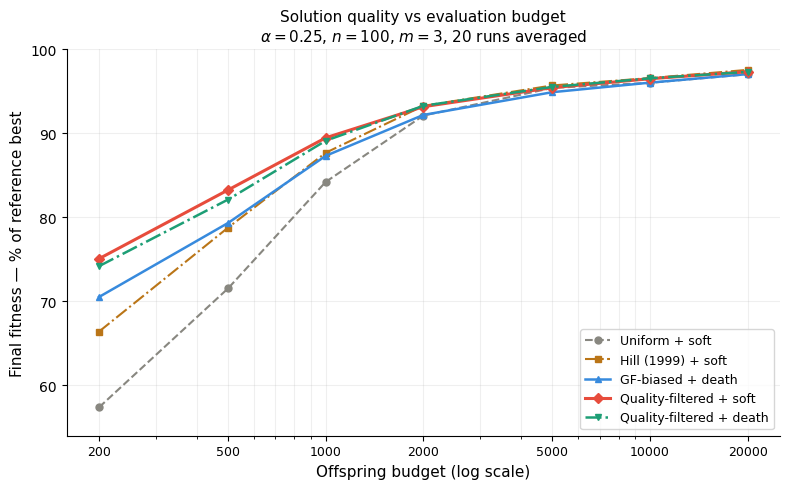

Saved.


In [7]:
DRIVE_DIR = '/content/drive/MyDrive/MKP_results'
TIMESTAMP = '20260507_181134'
BUDGETS   = [200, 500, 1000, 2000, 5000, 10000, 20000]

METHODS = {
    'uniform_soft':      {'label': 'Uniform + soft',          'color': '#888780', 'ls': '--',  'lw': 1.5, 'marker': 'o'},
    'hill_soft':         {'label': 'Hill (1999) + soft',      'color': '#BA7517', 'ls': '-.',  'lw': 1.5, 'marker': 's'},
    'gf_death':          {'label': 'GF-biased + death',       'color': '#378ADD', 'ls': '-',   'lw': 1.8, 'marker': '^'},
    'gf_filtered_soft':  {'label': 'Quality-filtered + soft', 'color': '#E74C3C', 'ls': '-',   'lw': 2.2, 'marker': 'D'},
    'gf_filtered_death': {'label': 'Quality-filtered + death','color': '#1D9E75', 'ls': '-.',  'lw': 1.8, 'marker': 'v'},
}

# Load all budget files
data = {}
for b in BUDGETS:
    fname = f"results_Budget_a025_b{b}_{TIMESTAMP}.json"
    with open(os.path.join(DRIVE_DIR, fname)) as f:
        d = json.load(f)
    for mkey in METHODS:
        if mkey not in data:
            data[mkey] = []
        runs   = d[mkey]
        finals = [r['pct_of_best_final'] for r in runs]
        data[mkey].append(np.mean(finals))

fig, ax = plt.subplots(figsize=(8, 5))

for mkey, style in METHODS.items():
    ax.plot(BUDGETS, data[mkey],
            label=style['label'],
            color=style['color'],
            ls=style['ls'],
            lw=style['lw'],
            marker=style['marker'],
            markersize=5)

ax.set_xscale('log')
ax.set_xticks(BUDGETS)
ax.set_xticklabels([str(b) for b in BUDGETS], fontsize=9)
ax.set_xlabel('Offspring budget (log scale)', fontsize=11)
ax.set_ylabel('Final fitness — % of reference best', fontsize=11)
ax.set_title(r'Solution quality vs evaluation budget'
             '\n' + r'$\alpha=0.25$, $n=100$, $m=3$, 20 runs averaged',
             fontsize=11)
ax.set_ylim(54, 100)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.2, which='both')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, f'fig_budget_sweep_{TIMESTAMP}.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(DRIVE_DIR, f'fig_budget_sweep_{TIMESTAMP}.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved.")

## Quality Filtering Seeding Sweep

In [8]:
# ============================================================
# CANDIDATE POOL SWEEP
# Fixed: alpha=0.25, budget=2000 (where differences are sharpest)
# Varying: n_candidates in {50, 100, 200, 400, 800, 1600}
# Question: at what pool size does quality-filtering saturate?
# Needs: setup cell + cached p_j
# ============================================================

N, M, ALPHA   = 100, 3, 0.25
REF_BEST      = 2375
INSTANCE_SEED = 42
PJ_SAMPLES    = 20_000_000
N_RUNS        = 20
MAX_OFFSPRING = 2000
CANDIDATE_VALUES = [50, 100, 200, 400, 800, 1600]
timestamp     = datetime.now().strftime("%Y%m%d_%H%M%S")

v, w, c = generate_instance(N, M, ALPHA, seed=INSTANCE_SEED)
vl = v.tolist(); wl = w.tolist(); cl = c.tolist()
pj     = get_pj(w, c, PJ_SAMPLES, n=N, m=M, alpha=ALPHA,
                instance_seed=INSTANCE_SEED)
hill_p = toyoda_heuristic(vl, wl, cl, N, M)

# Run fixed baselines once
print("Fixed baselines (budget=2000):")
baseline_runs = {}
for mkey, meth, pen in [('uniform_soft','uniform','soft'),
                         ('gf_death','gf','death')]:
    baseline_runs[mkey] = run_method(
        mkey, meth, pen, N_RUNS, MAX_OFFSPRING,
        N, M, vl, wl, cl, pj, hill_p, REF_BEST)
print()

# Sweep candidate pool size
print(f"Candidate pool sweep (budget={MAX_OFFSPRING}):")
print(f"{'Candidates':>12} {'filt_soft':>12} {'filt_death':>12} "
      f"{'gen0_quality':>14} {'conv90_soft':>13}")
print("─"*68)

summary = {}
all_results = {
    'label':   'Candidate pool sweep',
    'alpha':   float(ALPHA),
    'budget':  MAX_OFFSPRING,
    'ref':     REF_BEST,
    'baselines': baseline_runs,
    'sweep':   []
}

for n_cand in CANDIDATE_VALUES:
    soft_runs  = run_method(
        f'filt_soft_c{n_cand}', 'gf_filtered', 'soft',
        N_RUNS, MAX_OFFSPRING,
        N, M, vl, wl, cl, pj, hill_p, REF_BEST,
        n_candidates=n_cand)
    death_runs = run_method(
        f'filt_death_c{n_cand}', 'gf_filtered', 'death',
        N_RUNS, MAX_OFFSPRING,
        N, M, vl, wl, cl, pj, hill_p, REF_BEST,
        n_candidates=n_cand)

    soft_finals  = [r['pct_of_best_final'] for r in soft_runs]
    death_finals = [r['pct_of_best_final'] for r in death_runs]
    gen0q        = [r['pct_of_best_gen0']  for r in soft_runs]
    c90s         = [r['convergence'].get('90') for r in soft_runs
                    if r['convergence'].get('90')]
    c90str       = f"{np.mean(c90s):.0f}" if c90s else "never"

    print(f"{n_cand:>12}  "
          f"{np.mean(soft_finals):>10.1f}%  "
          f"{np.mean(death_finals):>10.1f}%  "
          f"{np.mean(gen0q):>12.1f}%ref  "
          f"{c90str:>12}")

    all_results['sweep'].append({
        'n_candidates':      int(n_cand),
        'filt_soft_final':   float(np.mean(soft_finals)),
        'filt_death_final':  float(np.mean(death_finals)),
        'gen0_quality_mean': float(np.mean(gen0q)),
        'conv90_soft':       float(np.mean(c90s)) if c90s else None,
        'filt_soft_runs':    soft_runs,
        'filt_death_runs':   death_runs,
    })

save_json(all_results,
          os.path.join(SAVE_DIR,
                       f"results_CandidateSweep_a025_b{MAX_OFFSPRING}_{timestamp}.json"))

print()
print(f"Baselines at budget={MAX_OFFSPRING} for reference:")
for mkey in ['uniform_soft','gf_death']:
    runs   = baseline_runs[mkey]
    finals = [r['pct_of_best_final'] for r in runs]
    c90s   = [r['convergence'].get('90') for r in runs
              if r['convergence'].get('90')]
    print(f"  {mkey:>14}: {np.mean(finals):.1f}%  "
          f"conv90={f'{np.mean(c90s):.0f}' if c90s else 'never'}")

  p_j loaded: pj_n100_m3_a025_seed42_20M.json
  [0.000,0.714] mean=0.249
Fixed baselines (budget=2000):
              uniform_soft: final=  92.1%  gen0=  0.0%  conv90=1481
                  gf_death: final=  92.2%  gen0= 49.8%  conv90=1298

Candidate pool sweep (budget=2000):
  Candidates    filt_soft   filt_death   gen0_quality   conv90_soft
────────────────────────────────────────────────────────────────────
             filt_soft_c50: final=  93.3%  gen0=100.0%  conv90=1132
            filt_death_c50: final=  92.8%  gen0=100.0%  conv90=1108
          50        93.3%        92.8%          62.4%ref          1132
            filt_soft_c100: final=  92.9%  gen0=100.0%  conv90=1125
           filt_death_c100: final=  93.2%  gen0=100.0%  conv90=1157
         100        92.9%        93.2%          62.6%ref          1125
            filt_soft_c200: final=  93.2%  gen0=100.0%  conv90=1060
           filt_death_c200: final=  93.0%  gen0=100.0%  conv90=1121
         200        93.2%        93.

## Noisy Objective Experiment

In [13]:
# ============================================================
# NOISY OBJECTIVE EXPERIMENT
# Robustness of GF-biased to objective uncertainty
# Consistent tracking: same fields as all other experiments
# No GPU needed — loads p_j from cache
# ============================================================

N, M, ALPHA   = 100, 3, 0.25
REF_BEST      = 2375
INSTANCE_SEED = 42
PJ_SAMPLES    = 20_000_000
N_RUNS        = 20
MAX_OFFSPRING = 1000
SIGMA_VALUES  = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
timestamp     = datetime.now().strftime("%Y%m%d_%H%M%S")

METHODS = [
    ('uniform_soft',     'uniform',      'soft'),
    ('hill_soft',        'hill',         'soft'),
    ('gf_death',         'gf',           'death'),
    ('gf_filtered_soft', 'gf_filtered',  'soft'),
]

v, w, c = generate_instance(N, M, ALPHA, seed=INSTANCE_SEED)
vl = v.tolist(); wl = w.tolist(); cl = c.tolist()
mean_v = float(np.mean(v))

pj     = get_pj(w, c, PJ_SAMPLES, n=N, m=M, alpha=ALPHA,
                instance_seed=INSTANCE_SEED)
hill_p_true = toyoda_heuristic(vl, wl, cl, N, M)
print(f"Hill global p (true) = {hill_p_true:.3f}")
print(f"Mean v = {mean_v:.1f}\n")

def add_noise(values, sigma_fraction, seed=0):
    rng   = np.random.RandomState(seed)
    noise = rng.normal(0, sigma_fraction * mean_v, len(values))
    return [max(0.1, values[j] + noise[j]) for j in range(len(values))]

all_results = {
    'label':        'Noisy objective experiment',
    'alpha':        float(ALPHA),
    'ref':          REF_BEST,
    'mean_v':       float(mean_v),
    'sigma_values': SIGMA_VALUES,
    'params': {
        'n': N, 'm': M,
        'instance_seed':  INSTANCE_SEED,
        'pj_seed':        42,
        'pj_samples':     PJ_SAMPLES,
        'pop_size':       50,
        'n_runs':         N_RUNS,
        'n_offspring':    MAX_OFFSPRING,
        'penalty_mult':   50.0,
        'convergence_thresholds': [50,60,70,80,90,95,98,99],
        'note': ('Noise corrupts v_j for Hill init and repair efficiency. '
                 'Fitness always evaluated on true v_j. '
                 'GF p_j computed from weights/capacities only.')
    },
    'sweep': []
}

print(f"{'Sigma':>7} {'uniform':>10} {'hill':>10} "
      f"{'gf_death':>10} {'gf_filt':>10} "
      f"{'hill_p':>8} {'conv90_gf':>11}")
print("─"*70)

for sigma in SIGMA_VALUES:
    noisy_vl     = add_noise(vl, sigma, seed=0)
    hill_p_noisy = toyoda_heuristic(noisy_vl, wl, cl, N, M)

    entry = {
        'sigma':          float(sigma),
        'hill_p_noisy':   float(hill_p_noisy),
        'hill_p_true':    float(hill_p_true),
        'methods':        {}
    }

    row_finals = {}
    row_c90    = {}

    for mkey, meth, pen in METHODS:
        hp = hill_p_noisy if meth == 'hill' else hill_p_true
        runs = []
        for r in range(N_RUNS):
            res = run_one_ga(
                N, M,
                vl,          # TRUE values for fitness always
                wl, cl,
                method=meth,
                penalty_type=pen,
                max_offspring=MAX_OFFSPRING,
                pj=pj,
                hill_p=hp,
                ref=REF_BEST,
                seed=r,
                track_diversity=False,
                track_every=50
            )
            runs.append(res)

        finals  = [r['pct_of_best_final']        for r in runs]
        gen0s   = [r['feasibility_rate_gen0']*100 for r in runs]
        c90s    = [r['convergence'].get('90')     for r in runs
                   if r['convergence'].get('90')]
        c90str  = f"{np.mean(c90s):.0f}" if c90s else "never"

        entry['methods'][mkey] = {
            'hill_p_used':    float(hp),
            'final_mean':     float(np.mean(finals)),
            'final_std':      float(np.std(finals)),
            'gen0_feas_mean': float(np.mean(gen0s)),
            'conv90_mean':    float(np.mean(c90s)) if c90s else None,
            'n_reached_90':   int(len(c90s)),
            'runs':           runs,
        }
        row_finals[mkey] = np.mean(finals)
        row_c90[mkey]    = c90str

    print(f"{sigma:>7.1f}  "
          f"{row_finals['uniform_soft']:>8.1f}%  "
          f"{row_finals['hill_soft']:>8.1f}%  "
          f"{row_finals['gf_death']:>8.1f}%  "
          f"{row_finals['gf_filtered_soft']:>8.1f}%  "
          f"{hill_p_noisy:>6.3f}  "
          f"{row_c90['gf_death']:>10}")

    all_results['sweep'].append(entry)

save_json(all_results,
          os.path.join(SAVE_DIR,
                       f"results_NoisyObjective_a025_{timestamp}.json"))

print(f"\nSaved. Fitness always on true v_j. "
      f"Noise only affects Hill init and repair ranking.")

  p_j loaded: pj_n100_m3_a025_seed42_20M.json
  [0.000,0.714] mean=0.249
Hill global p (true) = 0.310
Mean v = 50.7

  Sigma    uniform       hill   gf_death    gf_filt   hill_p   conv90_gf
──────────────────────────────────────────────────────────────────────
    0.0      84.2%      87.7%      87.3%      89.5%   0.310         905
    0.5      84.2%      88.2%      87.3%      89.5%   0.290         905
    1.0      84.2%      88.9%      87.3%      89.5%   0.260         905
    1.5      84.2%      88.9%      87.3%      89.5%   0.270         905
    2.0      84.2%      88.9%      87.3%      89.5%   0.260         905
    3.0      84.2%      88.9%      87.3%      89.5%   0.260         905
  Saved: /content/drive/MyDrive/MKP_results/results_NoisyObjective_a025_20260507_192440.json

Saved. Fitness always on true v_j. Noise only affects Hill init and repair ranking.
